<a href="https://colab.research.google.com/github/Light466/My_Programs/blob/main/SHAP_HYBRID_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#=========================================================
# Import Required Libraries
#=========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

import joblib

plt.style.use("ggplot")

print("="*80)
print("Libraries Imported Successfully")
print("="*80)

Libraries Imported Successfully


In [3]:
#=========================================================
# Install Required Libraries
#=========================================================

!pip -q install wordcloud
!pip -q install nltk
!pip -q install xgboost
!pip -q install lime
!pip -q install shap
!pip -q install tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
#=========================================================
# Download NLTK Resources
#=========================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK Resources Downloaded Successfully")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


NLTK Resources Downloaded Successfully


[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [5]:
#=========================================================
# Load Dataset from GitHub
#=========================================================

url = "https://raw.githubusercontent.com/Light466/My_Programs/main/symptoms_dataset.csv"

df = pd.read_csv(url)

print("="*80)
print("Dataset Loaded Successfully")
print("="*80)

print("Dataset Shape :", df.shape)

Dataset Loaded Successfully
Dataset Shape : (10700, 2)


In [6]:
df.head()

,Symptoms,Disease
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS)
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV)
2,nausea fatigue sometimes diarrhea or jaundice,Malaria
3,contractions Heavy vaginal bleeding,Late Miscarriage
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy


In [7]:
df.tail()

,Symptoms,Disease
10695,blurred vision Headaches fatigue difficulty co...,Post-Concussion Syndrome (PCS)
10696,fatigue digestive problems such as bloating or...,Pancreatic Cancer
10697,persistent itching or burning foul-smelling di...,Penile Cancer
10698,confusion about time or place poor judgment,Alzheimer’s Disease
10699,limited movement of the affected area or trunk...,Soft Tissue Sarcomas in Teenagers and Young Ad...


In [8]:
df.columns = [
    "Symptoms",
    "Disease"
]

df.head()

,Symptoms,Disease
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS)
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV)
2,nausea fatigue sometimes diarrhea or jaundice,Malaria
3,contractions Heavy vaginal bleeding,Late Miscarriage
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy


In [9]:
print("="*80)
print("Dataset Information")
print("="*80)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10700 entries, 0 to 10699
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Symptoms  10700 non-null  object
 1   Disease   10700 non-null  object
dtypes: object(2)
memory usage: 167.3+ KB


In [10]:
print("="*80)
print("Dataset Summary")
print("="*80)

df.describe(include="all")

Dataset Summary


,Symptoms,Disease
count,10700,10700
unique,10355,207
top,Usually no symptoms; in severe cases may cause...,Iron Deficiency Anemia
freq,10,100


In [11]:
print("="*80)
print("Missing Values")
print("="*80)

print(df.isnull().sum())

Missing Values
Symptoms    0
Disease     0
dtype: int64


In [12]:
df.dropna(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (10700, 2)


In [13]:
duplicates = df.duplicated().sum()

print("="*80)
print("Duplicate Records")
print("="*80)

print(duplicates)

Duplicate Records
309


In [14]:
df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

print("="*80)
print("Dataset Shape After Removing Duplicates")
print("="*80)

print(df.shape)

Dataset Shape After Removing Duplicates
(10391, 2)


In [15]:
print("="*80)
print("Total Diseases")
print("="*80)

print(df["Disease"].nunique())

Total Diseases
207


In [16]:
disease_counts = df["Disease"].value_counts()

print(disease_counts.head(20))

Disease
Insomnia                             100
Pneumonia                            100
Iron Deficiency Anemia                99
Delirium                              99
Skin and Scalp Psoriasis              99
Influenza                             98
Common cold                           98
Panic Disorder                        50
Polymyalgia Rheumatica (PMR)          50
Herpes                                50
Obesity in Adults                     50
Stomach Ache and Abdominal Pain       50
Polycythemia Vera                     50
Malaria                               50
Respiratory Syncytial Virus (RSV)     50
Iron Deficiency Anaemia               50
Heart Disease                         50
Hyperglycaemia                        50
Post-Concussion Syndrome (PCS)        50
Alzheimer’s Disease                   50
Name: count, dtype: int64


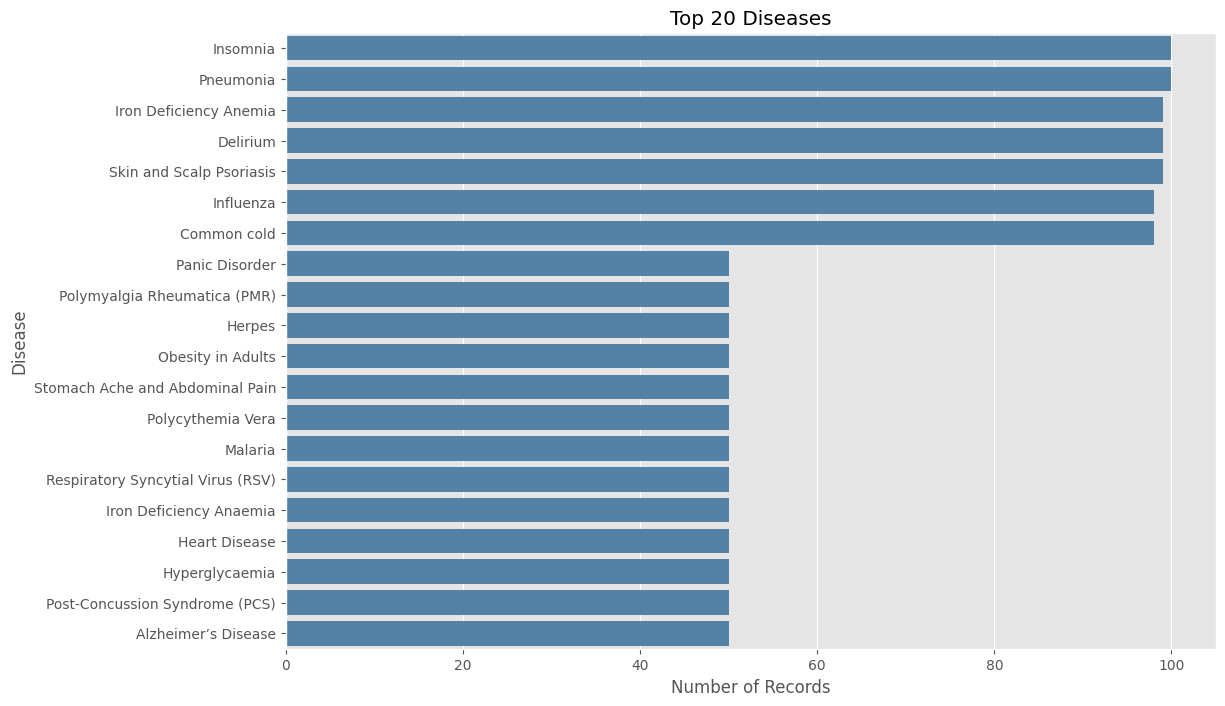

In [17]:
plt.figure(figsize=(12,8))

sns.barplot(

    x=disease_counts.head(20).values,

    y=disease_counts.head(20).index,

    color="steelblue"

)

plt.xlabel("Number of Records")

plt.ylabel("Disease")

plt.title("Top 20 Diseases")

plt.show()

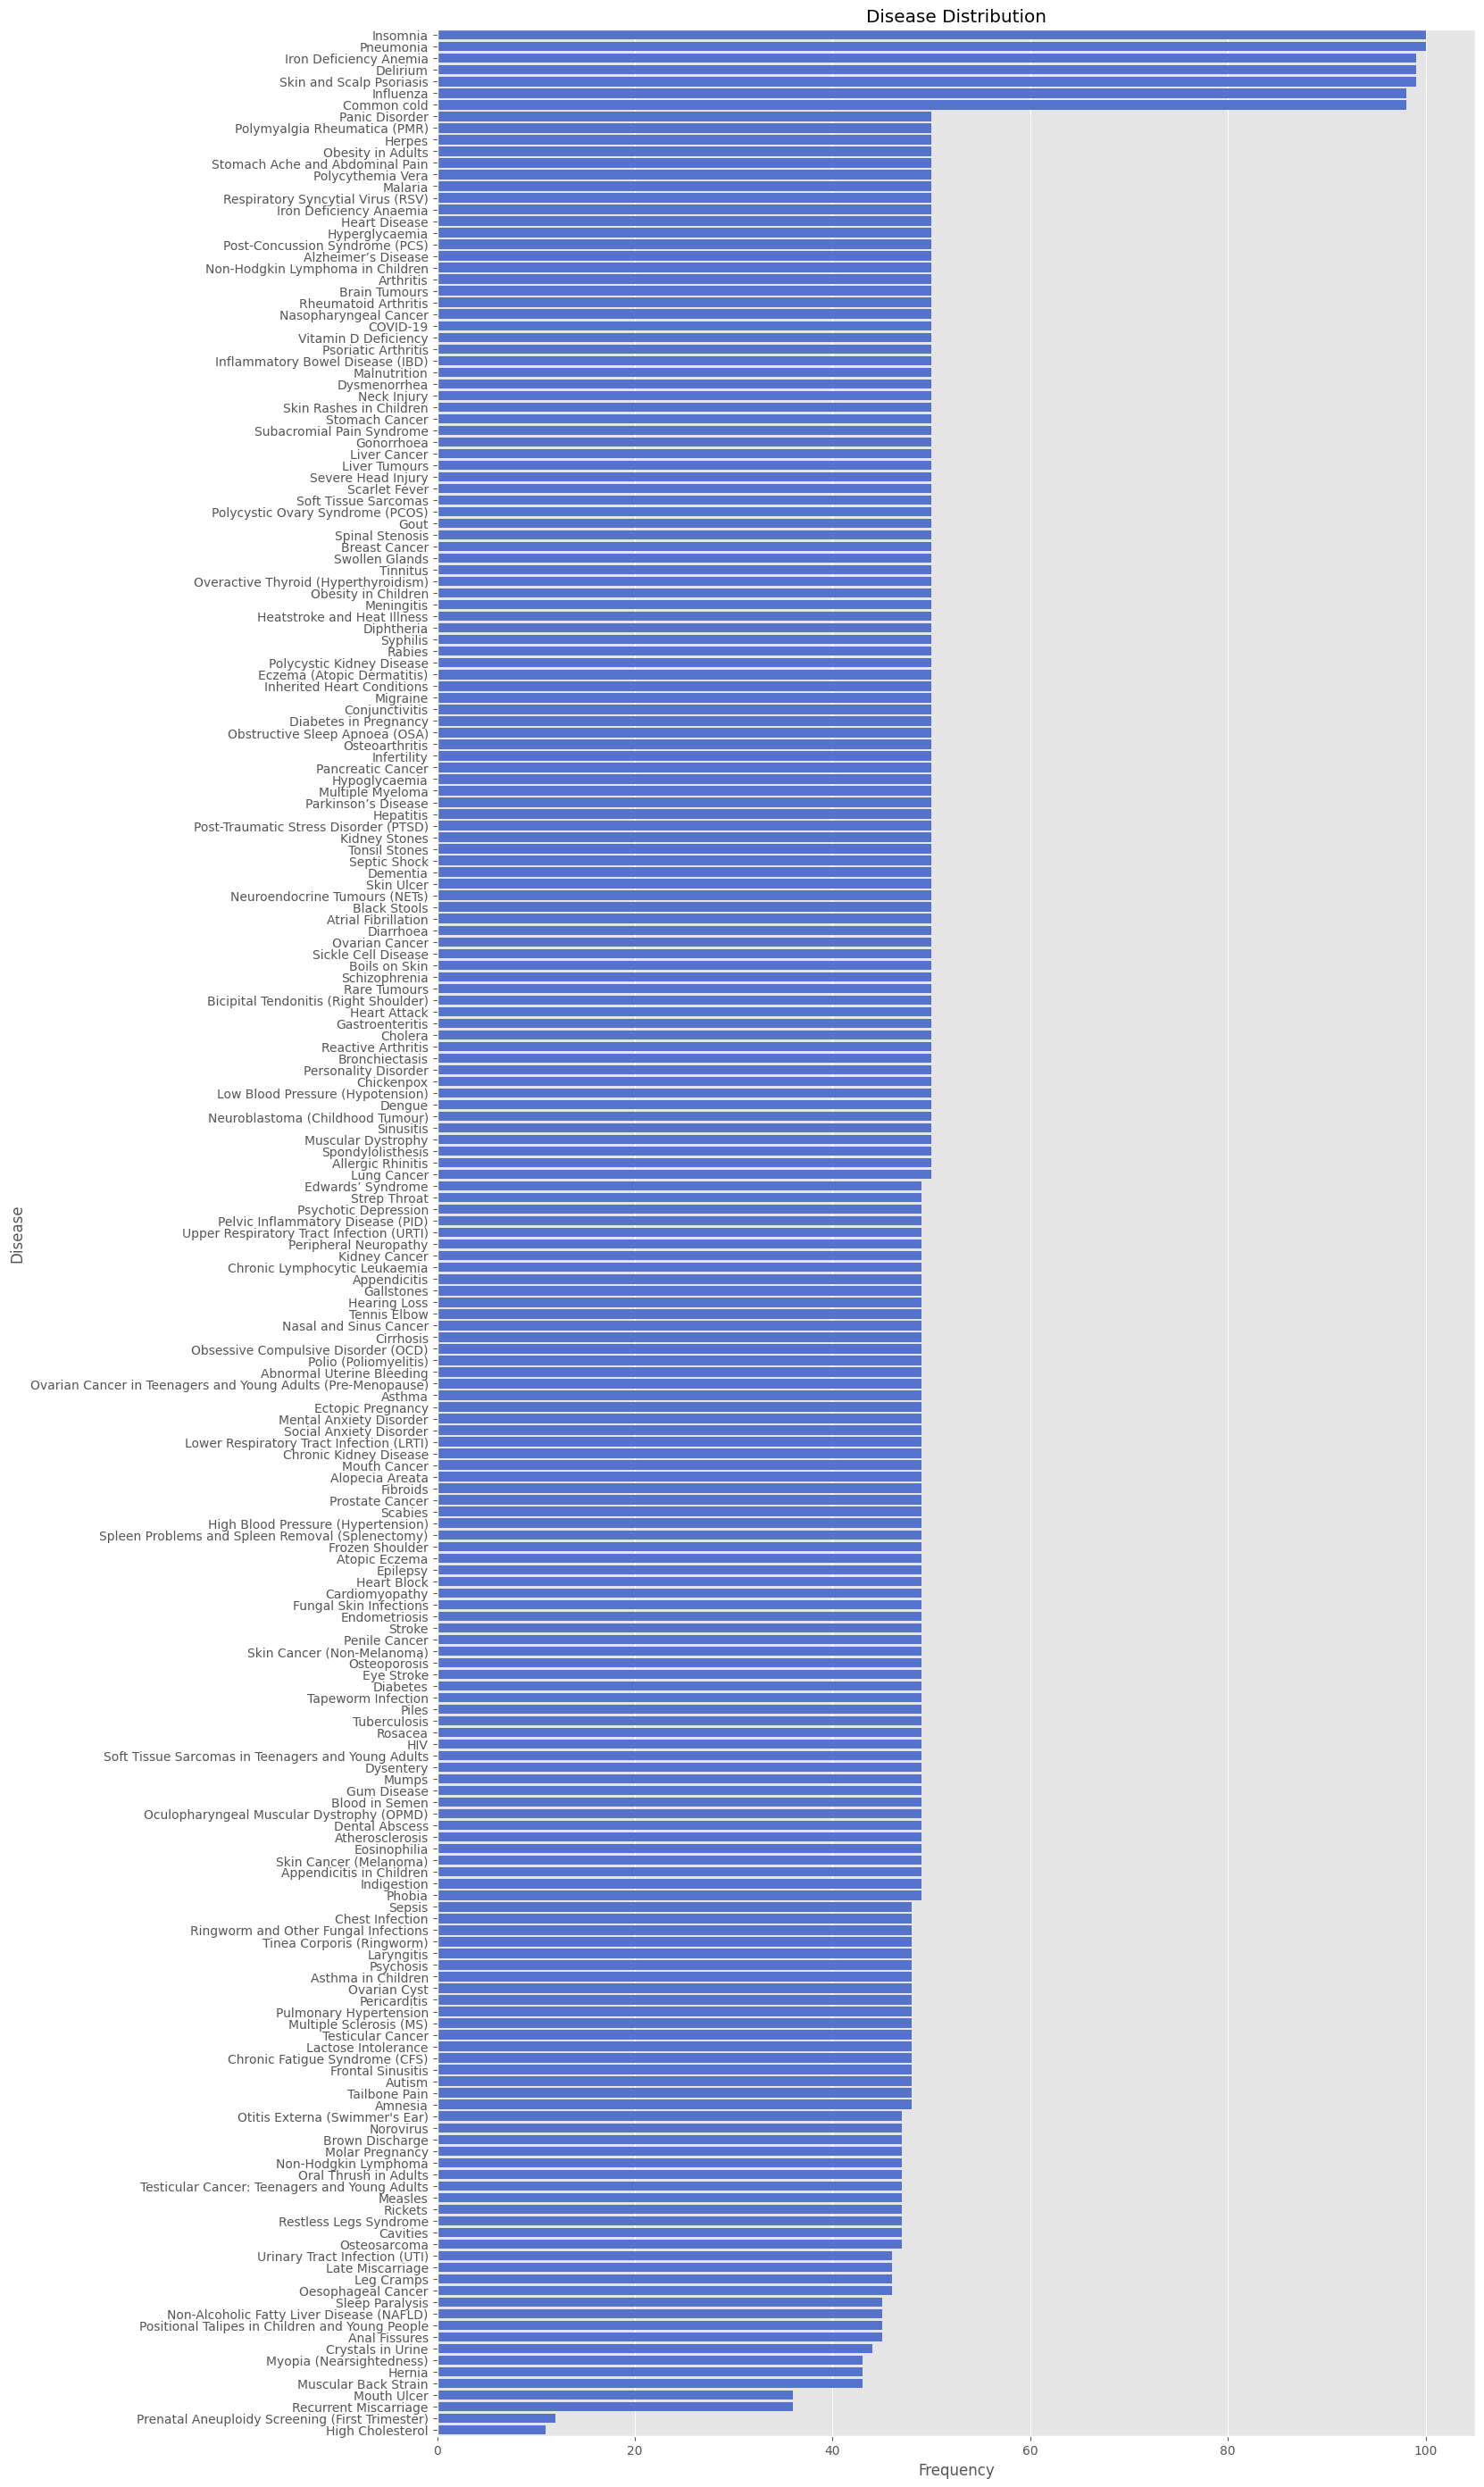

In [18]:
plt.figure(figsize=(15,35))

sns.countplot(

    y=df["Disease"],

    order=df["Disease"].value_counts().index,

    color="royalblue"

)

plt.xlabel("Frequency")

plt.ylabel("Disease")

plt.title("Disease Distribution")

plt.show()

In [19]:
df["Length"] = df["Symptoms"].apply(len)

df.head()

,Symptoms,Disease,Length
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45
3,contractions Heavy vaginal bleeding,Late Miscarriage,35
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95


In [20]:
print(df["Length"].describe())

count    10391.000000
mean        99.337311
std         46.966009
min          8.000000
25%         62.000000
50%         97.000000
75%        133.000000
max        268.000000
Name: Length, dtype: float64


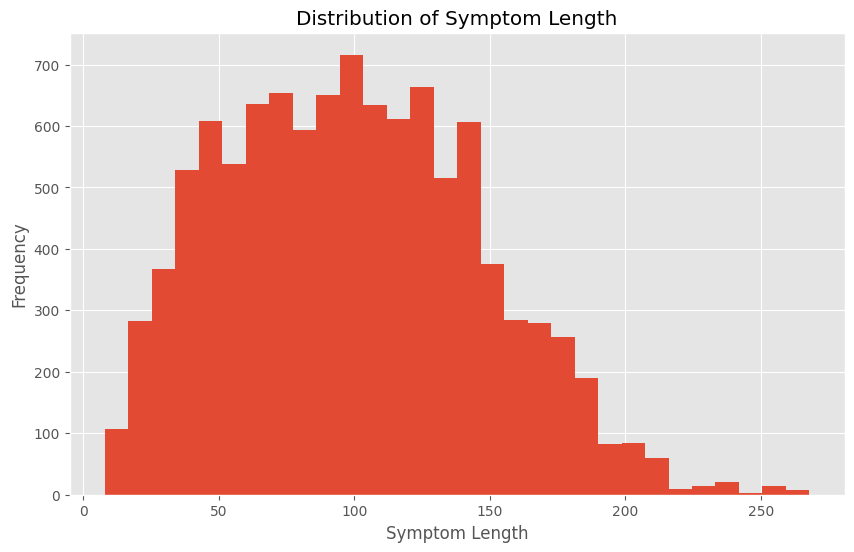

In [21]:
plt.figure(figsize=(10,6))

plt.hist(

    df["Length"],

    bins=30

)

plt.xlabel("Symptom Length")

plt.ylabel("Frequency")

plt.title("Distribution of Symptom Length")

plt.show()

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(

    stop_words="english"

)

X = vectorizer.fit_transform(

    df["Symptoms"]

)

words = vectorizer.get_feature_names_out()

counts = np.asarray(

    X.sum(axis=0)

).ravel()

word_freq = pd.DataFrame({

    "Word":words,

    "Frequency":counts

})

word_freq = word_freq.sort_values(

    by="Frequency",

    ascending=False

)

word_freq.head(20)

,Word,Frequency
587,pain,4295
298,fatigue,2575
494,loss,2051
221,difficulty,1817
306,fever,1592
825,swelling,1302
752,skin,1299
544,nausea,1164
7,abdominal,1107
943,weight,1044


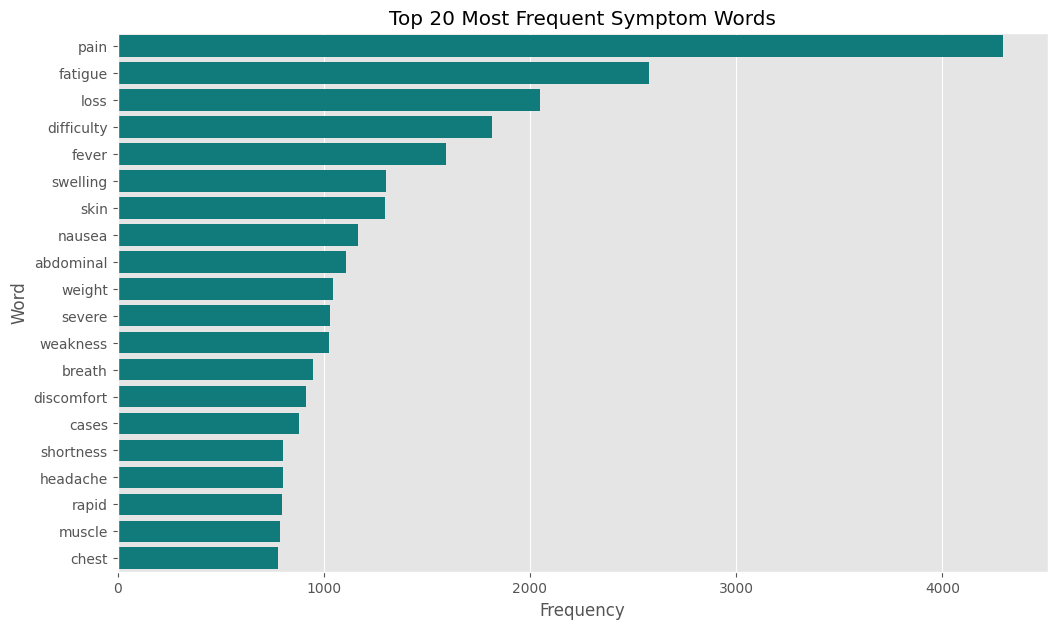

In [23]:
plt.figure(figsize=(12,7))

sns.barplot(

    data=word_freq.head(20),

    x="Frequency",

    y="Word",

    color="darkcyan"

)

plt.title("Top 20 Most Frequent Symptom Words")

plt.show()

In [24]:
print("="*80)

print(df["Disease"].value_counts().describe())

print("="*80)

count    207.000000
mean      50.198068
std       10.036071
min       11.000000
25%       49.000000
50%       49.000000
75%       50.000000
max      100.000000
Name: count, dtype: float64


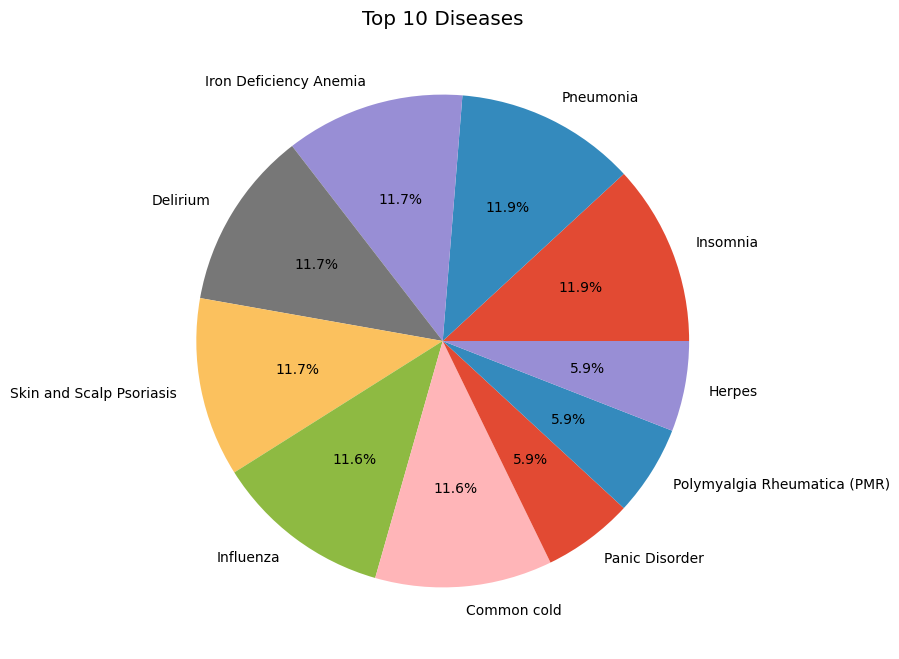

In [25]:
plt.figure(figsize=(8,8))

df["Disease"].value_counts().head(10).plot(

    kind="pie",

    autopct="%1.1f%%"

)

plt.ylabel("")

plt.title("Top 10 Diseases")

plt.show()

In [26]:
ambiguous = df.groupby("Symptoms")["Disease"].nunique()

ambiguous = ambiguous[ambiguous>1]

print("="*80)

print("Ambiguous Symptom Records")

print("="*80)

print(len(ambiguous))

ambiguous.head(20)

Ambiguous Symptom Records
31


,Disease
Symptoms,
Fever fatigue,2
Increased thirst fatigue,2
Wheezing chest tightness,2
dark urine loss of appetite,2
dizziness fatigue,3
fatigue abdominal swelling,2
fatigue blurred vision,2
fatigue fever,2
fatigue loss of appetite,2


In [27]:
print("="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print("Total Samples :",len(df))

print("Total Diseases :",df["Disease"].nunique())

print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Records :",duplicates)

print("="*80)

FINAL DATASET SUMMARY
Total Samples : 10391
Total Diseases : 207
Missing Values
Symptoms    0
Disease     0
Length      0
dtype: int64

Duplicate Records : 309


In [28]:
#=========================================================
# Text Cleaning
#=========================================================

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+"," ",text)

    text = re.sub(r"\d+"," ",text)

    text = text.translate(
        str.maketrans("","",string.punctuation)
    )

    text = re.sub(r"\s+"," ",text).strip()

    words = []

    for word in text.split():

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            words.append(word)

    return " ".join(words)

print("="*80)
print("Cleaning Symptoms...")
print("="*80)

df["Clean_Symptoms"] = df["Symptoms"].apply(clean_text)

df.head()

Cleaning Symptoms...


,Symptoms,Disease,Length,Clean_Symptoms
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129,fatigue numbness tingling bladder problem cogn...
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159,runny nose wheezing decreased appetite irritab...
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45,nausea fatigue sometimes diarrhea jaundice
3,contractions Heavy vaginal bleeding,Late Miscarriage,35,contraction heavy vaginal bleeding
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95,dizziness symptom early pregnancy missed perio...


In [29]:
for i in range(5):

    print("="*80)

    print("Original :")

    print(df["Symptoms"][i])

    print()

    print("Cleaned :")

    print(df["Clean_Symptoms"][i])

Original :
fatigue Numbness or tingling bladder problems cognitive difficulties dizziness difficulty walking muscle weakness vision problems

Cleaned :
fatigue numbness tingling bladder problem cognitive difficulty dizziness difficulty walking muscle weakness vision problem
Original :
Runny nose wheezing decreased appetite irritability in infants rapid or difficult breathing sneezing fever cough sometimes bluish lips or nails in severe cases

Cleaned :
runny nose wheezing decreased appetite irritability infant rapid difficult breathing sneezing fever cough sometimes bluish lip nail severe case
Original :
nausea fatigue sometimes diarrhea or jaundice

Cleaned :
nausea fatigue sometimes diarrhea jaundice
Original :
contractions Heavy vaginal bleeding

Cleaned :
contraction heavy vaginal bleeding
Original :
dizziness symptoms of early pregnancy such as missed period or nausea vaginal bleeding fainting

Cleaned :
dizziness symptom early pregnancy missed period nausea vaginal bleeding faint

In [30]:
#=========================================================
# Encode Disease Labels
#=========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Label"] = label_encoder.fit_transform(
    df["Disease"]
)

print("="*80)

print("Number of Diseases :",
      len(label_encoder.classes_))

print("="*80)

df.head()

Number of Diseases : 207


,Symptoms,Disease,Length,Clean_Symptoms,Label
0,fatigue Numbness or tingling bladder problems ...,Multiple Sclerosis (MS),129,fatigue numbness tingling bladder problem cogn...,104
1,Runny nose wheezing decreased appetite irritab...,Respiratory Syncytial Virus (RSV),159,runny nose wheezing decreased appetite irritab...,162
2,nausea fatigue sometimes diarrhea or jaundice,Malaria,45,nausea fatigue sometimes diarrhea jaundice,94
3,contractions Heavy vaginal bleeding,Late Miscarriage,35,contraction heavy vaginal bleeding,87
4,dizziness symptoms of early pregnancy such as ...,Ectopic Pregnancy,95,dizziness symptom early pregnancy missed perio...,46


In [31]:
disease_mapping = pd.DataFrame({

    "Disease":label_encoder.classes_,

    "Encoded_Label":range(
        len(label_encoder.classes_)
    )

})

disease_mapping.head()

,Disease,Encoded_Label
0,Abnormal Uterine Bleeding,0
1,Allergic Rhinitis,1
2,Alopecia Areata,2
3,Alzheimer’s Disease,3
4,Amnesia,4


In [32]:
disease_mapping.to_csv(

    "Disease_Label_Mapping.csv",

    index=False

)

print("Disease Mapping Saved Successfully")

Disease Mapping Saved Successfully


In [33]:
X = df["Clean_Symptoms"]

y = df["Label"]

print(X.shape)

print(y.shape)

(10391,)
(10391,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("="*80)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

print("="*80)

Training Samples : 8312
Testing Samples : 2079


In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    ngram_range=(1,2),

    max_features=8000,

    min_df=2,

    max_df=0.95,

    sublinear_tf=True

)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("="*80)

print("TF-IDF Created Successfully")

print("="*80)

print("Training Shape :",X_train_tfidf.shape)

print("Testing Shape :",X_test_tfidf.shape)

TF-IDF Created Successfully
Training Shape : (8312, 8000)
Testing Shape : (2079, 8000)


In [36]:
joblib.dump(

    tfidf,

    "TFIDF_Vectorizer.pkl"

)

print("TF-IDF Saved Successfully")

TF-IDF Saved Successfully


In [37]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

tfidf_scores = np.asarray(

    X_train_tfidf.mean(axis=0)

).ravel()

importance = pd.DataFrame({

    "Word":feature_names,

    "Score":tfidf_scores

})

importance = importance.sort_values(

    by="Score",

    ascending=False

)

importance.head(20)

,Word,Score
5019,pain,0.030608
2465,fatigue,0.024866
4219,loss,0.020177
2664,fever,0.018100
1723,difficulty,0.017594
4672,nausea,0.015500
6870,swelling,0.014896
3250,headache,0.014777
43,abdominal,0.013600
6168,skin,0.013370


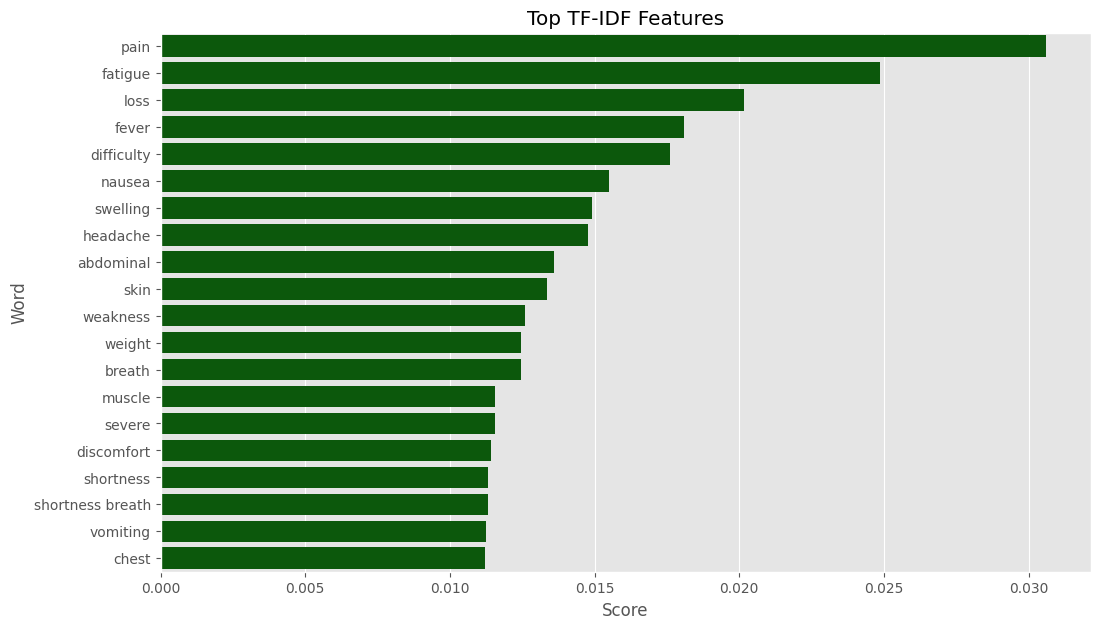

In [38]:
plt.figure(figsize=(12,7))

sns.barplot(

    data=importance.head(20),

    x="Score",

    y="Word",

    color="darkgreen"

)

plt.title("Top TF-IDF Features")

plt.show()

In [39]:
from sklearn.decomposition import TruncatedSVD

from sklearn.preprocessing import Normalizer

from sklearn.pipeline import Pipeline

print("="*80)

print("Applying TruncatedSVD")

print("="*80)

svd = TruncatedSVD(

    n_components=300,

    random_state=42

)

normalizer = Normalizer(copy=False)

svd_pipeline = Pipeline([

    ("svd",svd),

    ("normalize",normalizer)

])

X_train_svd = svd_pipeline.fit_transform(

    X_train_tfidf

)

X_test_svd = svd_pipeline.transform(

    X_test_tfidf

)

print("Original Shape :",X_train_tfidf.shape)

print("Reduced Shape :",X_train_svd.shape)

Applying TruncatedSVD
Original Shape : (8312, 8000)
Reduced Shape : (8312, 300)


In [40]:
variance = np.sum(

    svd.explained_variance_ratio_

)

print("="*80)

print("Explained Variance :",

      round(variance*100,2),

      "%")

print("="*80)

Explained Variance : 57.87 %


In [41]:
joblib.dump(

    svd_pipeline,

    "SVD_Model.pkl"

)

print("SVD Model Saved Successfully")

SVD Model Saved Successfully


In [42]:
from sklearn.svm import LinearSVC

from sklearn.model_selection import RandomizedSearchCV

param_grid = {

    "C":[

        0.1,

        0.5,

        1,

        2,

        5,

        10

    ],

    "class_weight":[

        None,

        "balanced"

    ]

}

svm = LinearSVC(

    random_state=42,

    dual=False,

    max_iter=5000

)

search = RandomizedSearchCV(

    svm,

    param_grid,

    n_iter=6,

    cv=5,

    scoring="accuracy",

    random_state=42,

    n_jobs=-1,

    verbose=2

)

print("="*80)

print("Training Optimized Linear SVM")

print("="*80)

search.fit(

    X_train_svd,

    y_train

)

best_svm = search.best_estimator_

print("="*80)

print("Best Parameters")

print(search.best_params_)

print("="*80)

Training Optimized Linear SVM
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters
{'class_weight': None, 'C': 0.5}


In [43]:
svm_train_scores = best_svm.decision_function(

    X_train_svd

)

svm_test_scores = best_svm.decision_function(

    X_test_svd

)

print("="*80)

print("Decision Score Shape")

print("="*80)

print(svm_train_scores.shape)

print(svm_test_scores.shape)

Decision Score Shape
(8312, 207)
(2079, 207)


In [44]:
import numpy as np

X_train_hybrid = np.concatenate(

    (

        X_train_svd,

        svm_train_scores

    ),

    axis=1

)

X_test_hybrid = np.concatenate(

    (

        X_test_svd,

        svm_test_scores

    ),

    axis=1

)

print("="*80)

print("Hybrid Feature Shape")

print("="*80)

print("Training :",X_train_hybrid.shape)

print("Testing :",X_test_hybrid.shape)

Hybrid Feature Shape
Training : (8312, 507)
Testing : (2079, 507)


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_hybrid = scaler.fit_transform(

    X_train_hybrid

)

X_test_hybrid = scaler.transform(

    X_test_hybrid

)

print("="*80)

print("Hybrid Features Standardized")

print("="*80)

Hybrid Features Standardized


In [47]:
joblib.dump(

    best_svm,

    "Linear_SVM.pkl"

)

joblib.dump(

    scaler,

    "Hybrid_Scaler.pkl"

)

print("="*80)

print("All Models Saved Successfully")

print("="*80)

All Models Saved Successfully


In [48]:
print("="*100)

print("PART 2 COMPLETED SUCCESSFULLY")

print("="*100)

print("Training TF-IDF :",X_train_tfidf.shape)

print("Training SVD :",X_train_svd.shape)

print("Training Hybrid :",X_train_hybrid.shape)

print()

print("Testing TF-IDF :",X_test_tfidf.shape)

print("Testing SVD :",X_test_svd.shape)

print("Testing Hybrid :",X_test_hybrid.shape)

print()

print("Number of Diseases :",len(label_encoder.classes_))

print("="*100)

PART 2 COMPLETED SUCCESSFULLY
Training TF-IDF : (8312, 8000)
Training SVD : (8312, 300)
Training Hybrid : (8312, 507)

Testing TF-IDF : (2079, 8000)
Testing SVD : (2079, 300)
Testing Hybrid : (2079, 507)

Number of Diseases : 207


In [49]:
#=========================================================
# Deep Learning Libraries
#=========================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Input

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.regularizers import l2

print("="*100)
print("TensorFlow Version :",tf.__version__)
print("="*100)

TensorFlow Version : 2.20.0


In [50]:
#=========================================================
# Reproducibility
#=========================================================

np.random.seed(42)

tf.random.set_seed(42)

In [51]:
num_classes = len(label_encoder.classes_)

print("="*100)

print("Total Diseases :",num_classes)

print("="*100)

Total Diseases : 207


In [52]:
input_dimension = X_train_hybrid.shape[1]

print("Hybrid Feature Dimension :",input_dimension)

Hybrid Feature Dimension : 507


In [53]:
#=========================================================
# Hybrid AI Model
#=========================================================

model = Sequential()

#--------------------------------------------------
# Input Layer
#--------------------------------------------------

model.add(

    Input(

        shape=(input_dimension,)

    )

)

#--------------------------------------------------
# Hidden Layer 1
#--------------------------------------------------

model.add(

    Dense(

        512,

        activation="relu",

        kernel_regularizer=l2(0.0005)

    )

)

model.add(BatchNormalization())

model.add(Dropout(0.30))

#--------------------------------------------------
# Hidden Layer 2
#--------------------------------------------------

model.add(

    Dense(

        256,

        activation="relu",

        kernel_regularizer=l2(0.0005)

    )

)

model.add(BatchNormalization())

model.add(Dropout(0.25))

#--------------------------------------------------
# Hidden Layer 3
#--------------------------------------------------

model.add(

    Dense(

        128,

        activation="relu",

        kernel_regularizer=l2(0.0001)

    )

)

model.add(BatchNormalization())

model.add(Dropout(0.20))

#--------------------------------------------------
# Hidden Layer 4
#--------------------------------------------------

model.add(

    Dense(

        64,

        activation="relu"

    )

)

model.add(Dropout(0.15))

#--------------------------------------------------
# Hidden Layer 5
#--------------------------------------------------

model.add(

    Dense(

        32,

        activation="relu"

    )

)

#--------------------------------------------------
# Output Layer
#--------------------------------------------------

model.add(

    Dense(

        num_classes,

        activation="softmax"

    )

)

In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       260,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 207)            │         6,831 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,071 (1.70 MB)

 Trainable params: 443,279 (1.69 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [55]:
optimizer = Adam(

    learning_rate=0.001

)

model.compile(

    optimizer=optimizer,

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("="*100)

print("Hybrid AI Model Compiled Successfully")

print("="*100)

Hybrid AI Model Compiled Successfully


In [56]:
early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

In [57]:
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

In [58]:
checkpoint = ModelCheckpoint(

    "Best_Hybrid_Model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

In [59]:
print("="*100)

print("Training Hybrid AI Model")

print("="*100)

history = model.fit(

    X_train_hybrid,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=64,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    verbose=1

)

Training Hybrid AI Model
Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.0599 - loss: 5.4591
Epoch 1: val_accuracy improved from None to 0.58388, saving model to Best_Hybrid_Model.keras

Epoch 1: finished saving model to Best_Hybrid_Model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.1484 - loss: 4.9246 - val_accuracy: 0.5839 - val_loss: 3.2790 - learning_rate: 0.0010
Epoch 2/100
101/104 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5986 - loss: 2.6176
Epoch 2: val_accuracy improved from 0.58388 to 0.92544, saving model to Best_Hybrid_Model.keras

Epoch 2: finished saving model to Best_Hybrid_Model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7061 - loss: 2.0636 - val_accuracy: 0.9254 - val_loss: 0.9291 - learning_rate: 0.0010
Epoch 3/100
100/104 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8755 - loss: 1.1284
Epoch 3: val_accuracy improved from 0.92544 to 0.93385, saving model to Best_Hybrid_Model.keras

Epoch 3: finished savi

In [60]:
from tensorflow.keras.models import load_model

model = load_model(

    "Best_Hybrid_Model.keras"

)

print("="*100)

print("Best Model Loaded Successfully")

print("="*100)

Best Model Loaded Successfully


In [61]:
train_loss, train_accuracy = model.evaluate(

    X_train_hybrid,

    y_train,

    verbose=0

)

print("="*100)

print("Training Accuracy :",

      round(train_accuracy*100,2),

      "%")

print("="*100)

Training Accuracy : 98.53 %


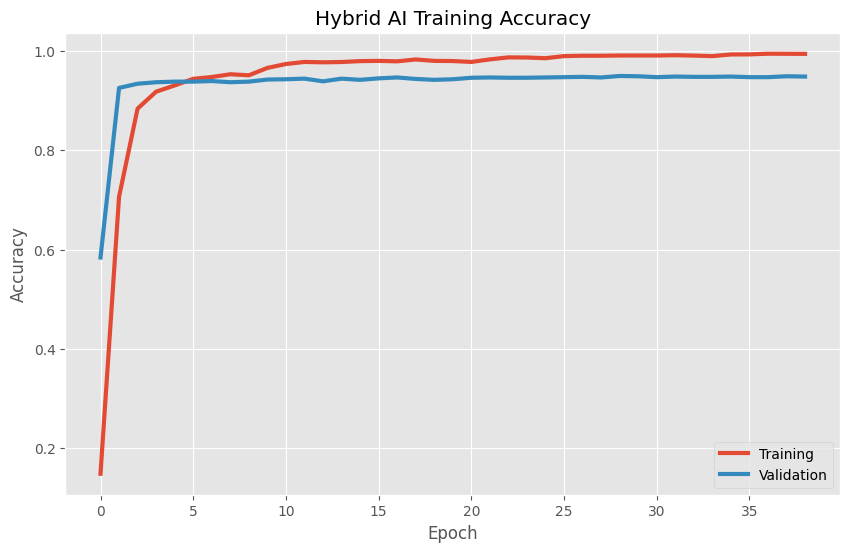

In [62]:
plt.figure(figsize=(10,6))

plt.plot(

    history.history["accuracy"],

    linewidth=3,

    label="Training"

)

plt.plot(

    history.history["val_accuracy"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Hybrid AI Training Accuracy")

plt.legend()

plt.grid(True)

plt.show()

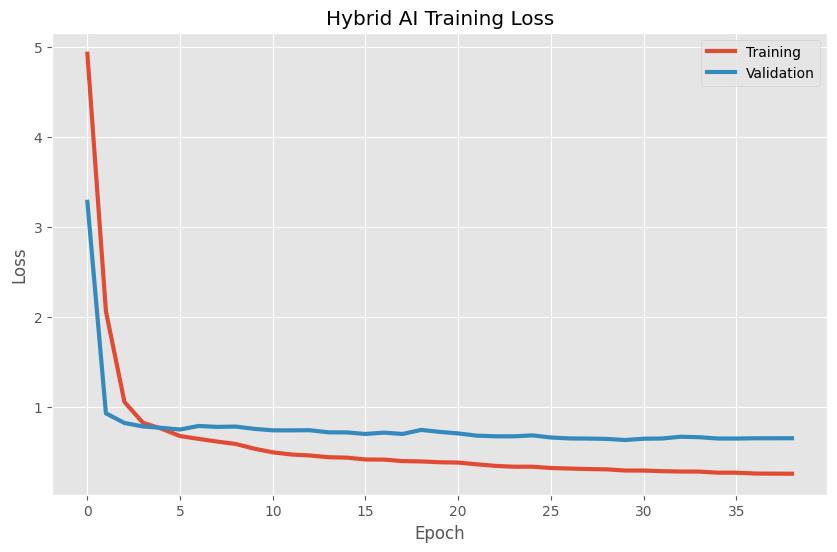

In [63]:
plt.figure(figsize=(10,6))

plt.plot(

    history.history["loss"],

    linewidth=3,

    label="Training"

)

plt.plot(

    history.history["val_loss"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Hybrid AI Training Loss")

plt.legend()

plt.grid(True)

plt.show()

In [65]:
history_df = pd.DataFrame(

    history.history

)

history_df.to_csv(

    "Training_History.csv",

    index=False

)

print("="*100)

print("Training History Saved Successfully")

print("="*100)

Training History Saved Successfully


In [66]:
model.save(

    "Hybrid_AI_Model.keras"

)

print("="*100)

print("Hybrid AI Model Saved Successfully")

print("="*100)

Hybrid AI Model Saved Successfully


In [67]:
print("="*100)

print("PART 3A COMPLETED SUCCESSFULLY")

print("="*100)

print("Input Features :",X_train_hybrid.shape[1])

print("Disease Classes :",num_classes)

print("Training Samples :",len(X_train_hybrid))

print("Testing Samples :",len(X_test_hybrid))

print("="*100)

PART 3A COMPLETED SUCCESSFULLY
Input Features : 507
Disease Classes : 207
Training Samples : 8312
Testing Samples : 2079


In [68]:
#=========================================================
# Model Evaluation
#=========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [69]:
#=========================================================
# Linear SVM Prediction
#=========================================================

svm_pred = best_svm.predict(X_test_svd)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
) * 100

svm_precision = precision_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

svm_recall = recall_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
) * 100

print("="*100)
print("LINEAR SVM PERFORMANCE")
print("="*100)

print(f"Accuracy  : {svm_accuracy:.2f}%")
print(f"Precision : {svm_precision:.2f}%")
print(f"Recall    : {svm_recall:.2f}%")
print(f"F1-Score  : {svm_f1:.2f}%")

print("="*100)

LINEAR SVM PERFORMANCE
Accuracy  : 96.97%
Precision : 97.22%
Recall    : 96.97%
F1-Score  : 96.94%


In [70]:
#=========================================================
# Hybrid AI Prediction
#=========================================================

hybrid_prob = model.predict(
    X_test_hybrid,
    verbose=0
)

hybrid_pred = np.argmax(
    hybrid_prob,
    axis=1
)

hybrid_accuracy = accuracy_score(
    y_test,
    hybrid_pred
) * 100

hybrid_precision = precision_score(
    y_test,
    hybrid_pred,
    average="weighted",
    zero_division=0
) * 100

hybrid_recall = recall_score(
    y_test,
    hybrid_pred,
    average="weighted",
    zero_division=0
) * 100

hybrid_f1 = f1_score(
    y_test,
    hybrid_pred,
    average="weighted",
    zero_division=0
) * 100

print("="*100)
print("HYBRID AI MODEL PERFORMANCE")
print("="*100)

print(f"Accuracy  : {hybrid_accuracy:.2f}%")
print(f"Precision : {hybrid_precision:.2f}%")
print(f"Recall    : {hybrid_recall:.2f}%")
print(f"F1-Score  : {hybrid_f1:.2f}%")

print("="*100)

HYBRID AI MODEL PERFORMANCE
Accuracy  : 96.15%
Precision : 96.43%
Recall    : 96.15%
F1-Score  : 96.15%


In [71]:
print("="*100)
print("HYBRID AI CLASSIFICATION REPORT")
print("="*100)

print(

    classification_report(

        y_test,

        hybrid_pred,

        zero_division=0

    )

)

HYBRID AI CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      0.90      0.95        10
           5       1.00      1.00      1.00         9
           6       1.00      0.90      0.95        10
           7       1.00      0.90      0.95        10
           8       0.70      0.70      0.70        10
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        10
          11       1.00      1.00      1.00        10
          12       1.00      1.00      1.00        10
          13       0.91      1.00      0.95        10
          14       1.00      1.00      1.00         9
          15       1.00      1.00      1.00        10
          16       0.91      1.00      0.95      

In [72]:
cm = confusion_matrix(
    y_test,
    hybrid_pred
)

print(cm)

[[10  0  0 ...  0  0  0]
 [ 0  9  0 ...  0  0  0]
 [ 0  0 10 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0  9  0]
 [ 0  0  0 ...  0  0 10]]


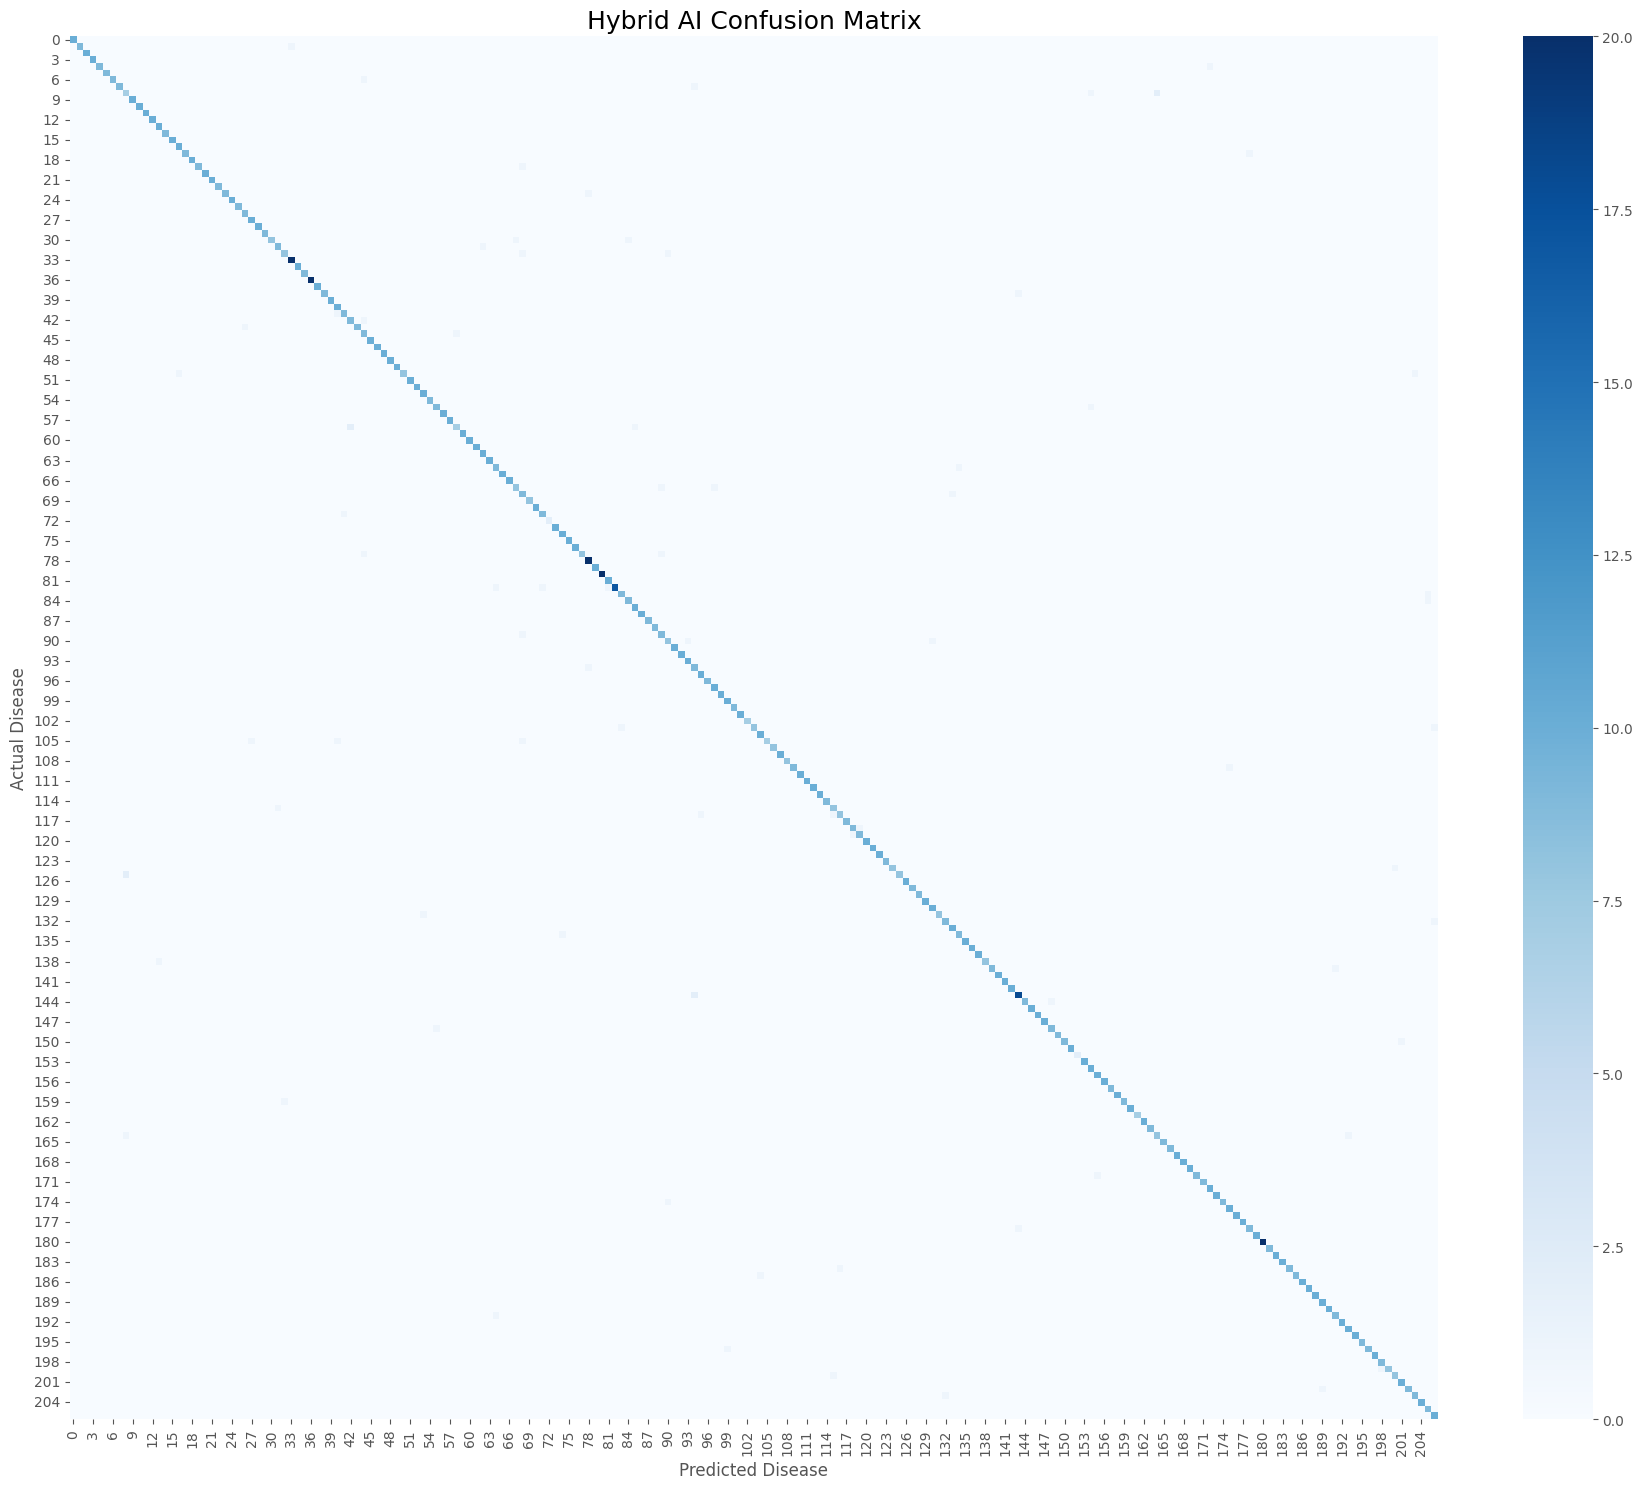

In [73]:
plt.figure(figsize=(18,15))

sns.heatmap(

    cm,

    cmap="Blues",

    cbar=True

)

plt.title(
    "Hybrid AI Confusion Matrix",
    fontsize=18
)

plt.xlabel(
    "Predicted Disease"
)

plt.ylabel(
    "Actual Disease"
)

plt.tight_layout()

plt.show()

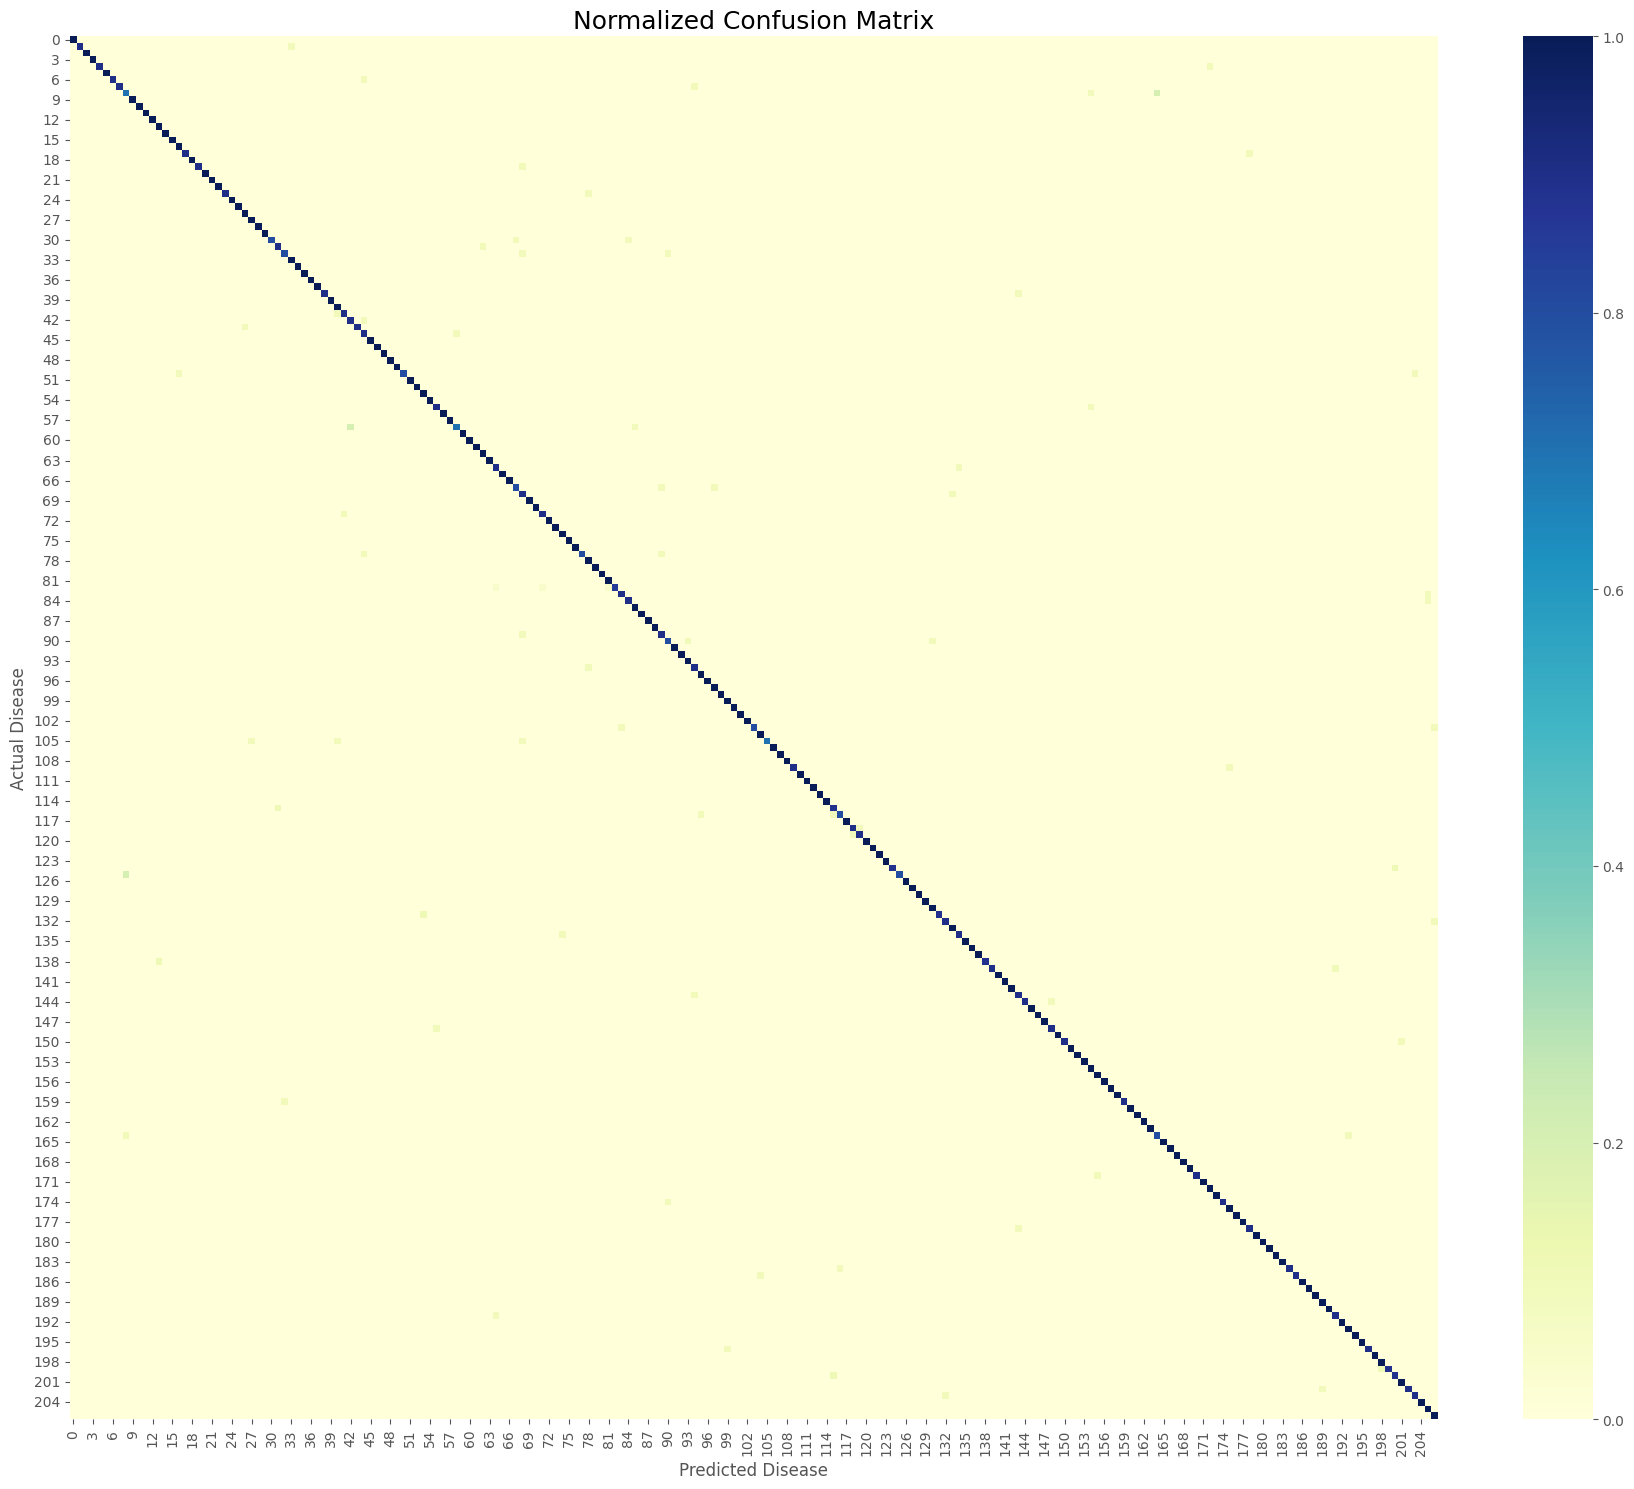

In [74]:
cm_norm = confusion_matrix(

    y_test,

    hybrid_pred,

    normalize="true"

)

plt.figure(figsize=(18,15))

sns.heatmap(

    cm_norm,

    cmap="YlGnBu",

    cbar=True

)

plt.title(
    "Normalized Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Disease")

plt.ylabel("Actual Disease")

plt.tight_layout()

plt.show()

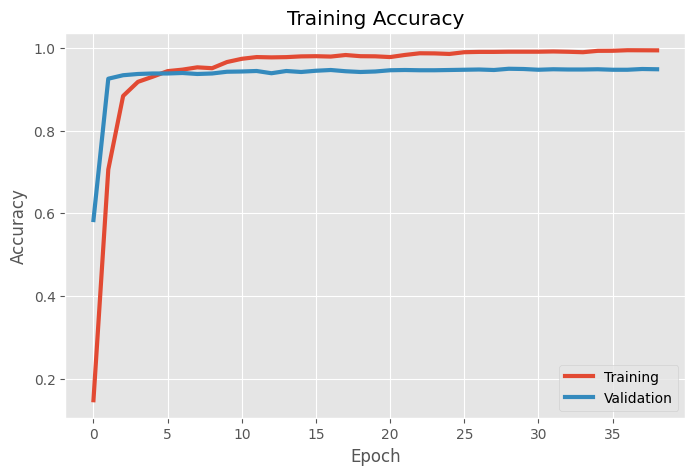

In [75]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    linewidth=3,

    label="Training"

)

plt.plot(

    history.history["val_accuracy"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.grid(True)

plt.show()

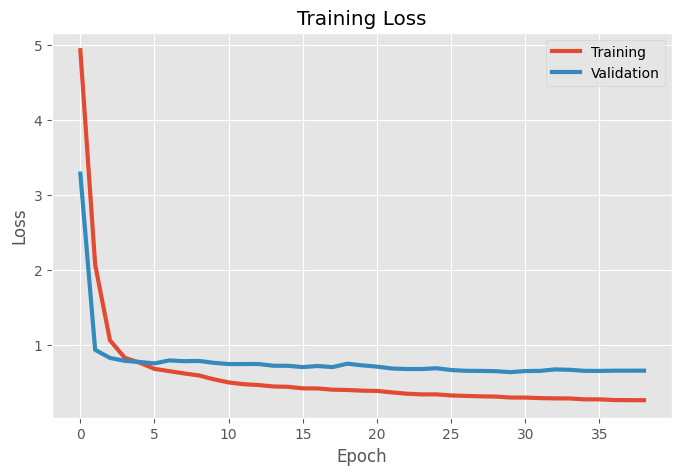

In [76]:
plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    linewidth=3,

    label="Training"

)

plt.plot(

    history.history["val_loss"],

    linewidth=3,

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid(True)

plt.show()

In [77]:
results = pd.DataFrame({

    "Model":[

        "Linear SVM",

        "Hybrid AI"

    ],

    "Accuracy":[

        svm_accuracy,

        hybrid_accuracy

    ],

    "Precision":[

        svm_precision,

        hybrid_precision

    ],

    "Recall":[

        svm_recall,

        hybrid_recall

    ],

    "F1-Score":[

        svm_f1,

        hybrid_f1

    ]

})

results = results.round(2)

print(results)

        Model  Accuracy  Precision  Recall  F1-Score
0  Linear SVM     96.97      97.22   96.97     96.94
1   Hybrid AI     96.15      96.43   96.15     96.15


In [79]:
results.to_csv(

    "Model_Comparison.csv",

    index=False

)

print("Results Saved Successfully")

Results Saved Successfully


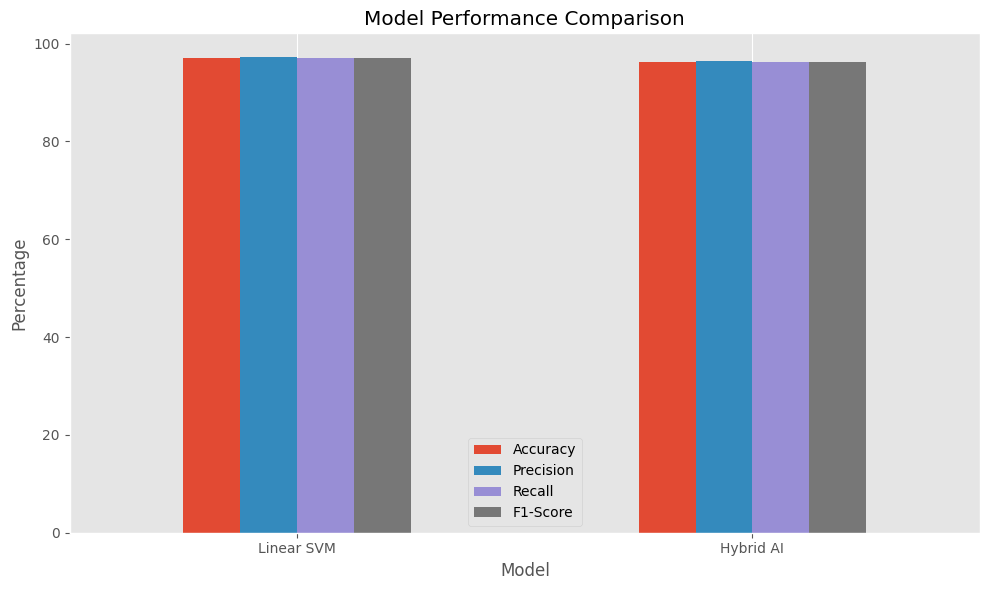

In [80]:
results_plot = results.set_index("Model")

results_plot.plot(

    kind="bar",

    figsize=(10,6)

)

plt.ylabel("Percentage")

plt.title("Model Performance Comparison")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [81]:
if hybrid_accuracy > svm_accuracy:

    best_model = "Hybrid AI"

    best_accuracy = hybrid_accuracy

else:

    best_model = "Linear SVM"

    best_accuracy = svm_accuracy

print("="*100)

print("BEST MODEL")

print("="*100)

print("Model :", best_model)

print(f"Accuracy : {best_accuracy:.2f}%")

print("="*100)

BEST MODEL
Model : Linear SVM
Accuracy : 96.97%
